### Setup

In [83]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [84]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

device

'cuda'

### Load Dataset

In [85]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", ]

df = pd.read_csv(url, names=columns, na_values="?", sep=r"\s+", usecols=range(8), )

df = df.dropna()

df = df.dropna()

print(df.shape)

df.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


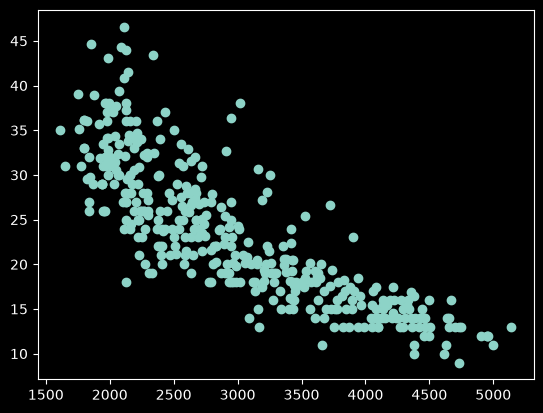

In [86]:
plt.scatter(df[["weight"]].values, df[["mpg"]].values)

In [87]:
X = torch.tensor(df[["weight"]].values, dtype=torch.float32, device=device)

y = torch.tensor(df[["mpg"]].values, dtype=torch.float32, device=device)

In [88]:
X_mean = X.mean()
X_std = X.std()
X = (X-X_mean)/X_std

y_mean = y.mean()
y_std = y.std()
y = (y-y_mean)/y_std

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([313, 1]),
 torch.Size([79, 1]),
 torch.Size([313, 1]),
 torch.Size([79, 1]))

### Model

In [90]:
class ModelNNN(nn.Module):
    def __init__(self, input_n, n, output_n):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(input_n, n))
        self.output_layer = nn.Linear(n, output_n)

    def forward(self, X):
        block_output = self.block(X)
        return self.output_layer(block_output)

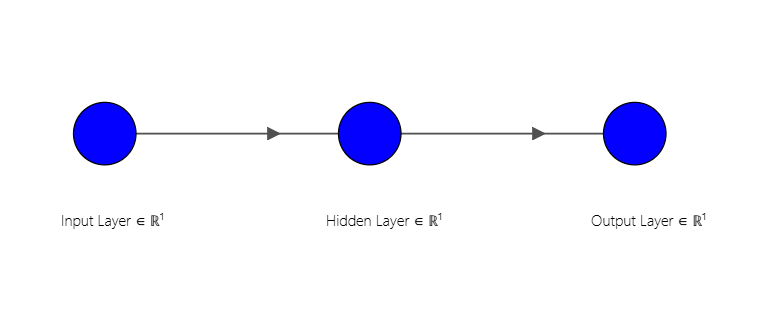

In [91]:
model = ModelNNN(1, 1, 1)
model = model.to(device)
model

ModelNNN(
  (block): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
  )
  (output_layer): Linear(in_features=1, out_features=1, bias=True)
)

### Training

In [92]:
def train(model, optimizer, criterion, X, y, n_epochs):
    losses = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")
    return losses

In [93]:
learning_rate = 0.1
n_epochs = 30

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [94]:
loss = train(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/30, Loss: 0.848500669002533
Epoch 2/30, Loss: 0.5489763617515564
Epoch 3/30, Loss: 0.415811687707901
Epoch 4/30, Loss: 0.3628266155719757
Epoch 5/30, Loss: 0.3435249626636505
Epoch 6/30, Loss: 0.3365323543548584
Epoch 7/30, Loss: 0.33375847339630127
Epoch 8/30, Loss: 0.3324921131134033
Epoch 9/30, Loss: 0.3318398594856262
Epoch 10/30, Loss: 0.33147886395454407
Epoch 11/30, Loss: 0.3312722146511078
Epoch 12/30, Loss: 0.3311523497104645
Epoch 13/30, Loss: 0.3310825228691101
Epoch 14/30, Loss: 0.3310418128967285
Epoch 15/30, Loss: 0.3310180902481079
Epoch 16/30, Loss: 0.33100426197052
Epoch 17/30, Loss: 0.33099621534347534
Epoch 18/30, Loss: 0.33099156618118286
Epoch 19/30, Loss: 0.3309888541698456
Epoch 20/30, Loss: 0.33098727464675903
Epoch 21/30, Loss: 0.3309863805770874
Epoch 22/30, Loss: 0.3309858441352844
Epoch 23/30, Loss: 0.33098554611206055
Epoch 24/30, Loss: 0.3309853971004486
Epoch 25/30, Loss: 0.33098524808883667
Epoch 26/30, Loss: 0.3309852182865143
Epoch 27/30, Loss:

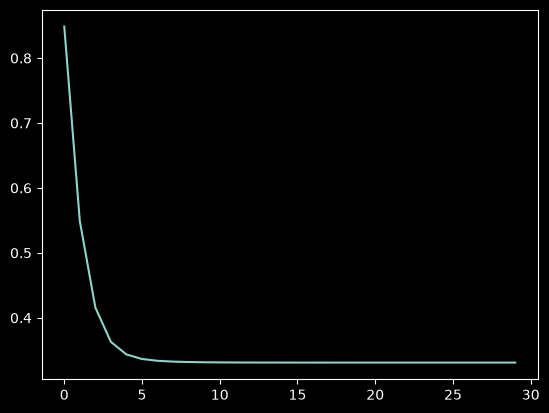

In [95]:
plt.plot(list(range(n_epochs)), loss)

### Evaluate

In [96]:
def evaluate(model, X, y, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_data, y_data in zip(X, y):
            y_pred = model(X_data)
            metric = metric_fn(y_pred, y_data)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [97]:
evaluate(model, X_test, y_test, mse)

tensor(0.2100, device='cuda:0')

end